In [115]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from decimal import Decimal, getcontext, ROUND_HALF_EVEN

# Методичка

In [116]:
# ВНИМАНИЕ! в этой ячейке злостный вайбкод, но я его тестил

def round_err(epsilon_raw):
    """
    Округляет погрешность по правилам:
      - если первая значащая цифра 1–3 → 2 значащие;
      - иначе → 1 значащая.
    Возвращает:
        (ε_rounded: float, ε_str: str)
    """
    if epsilon_raw is None or math.isnan(epsilon_raw):
        return float('nan'), "undefined"
    if epsilon_raw == 0:
        return "0"

    n_sig = significant_digits_count(epsilon_raw)
    eps_rounded = round_to_significant_decimal(epsilon_raw, n_sig)

    # вычисляем, сколько знаков после запятой нужно
    if eps_rounded < 1:
        dec_places = decimal_places_for_value_decimal(eps_rounded, n_sig)
    else:
        exp_rel = math.floor(math.log10(eps_rounded))
        dec_places = max(0, n_sig - 1 - exp_rel)

    # без ".0", если dec_places == 0
    eps_str = format_number_decimal(eps_rounded, dec_places, force_decimals=(dec_places > 0))
    return eps_str


getcontext().prec = 40

def significant_digits_count(value):
    if value == 0 or (isinstance(value, float) and math.isnan(value)):
        return 1
    d = Decimal(str(value)).normalize()
    s = ''.join(map(str, d.as_tuple().digits))
    if not s:
        return 1
    first = int(s[0])
    return 2 if first in (1,2,3) else 1

def round_to_significant_decimal(x, n):
    """Возвращает Decimal, округлённый до n значащих цифр (half-even)."""
    if x == 0:
        return Decimal(0)
    d = Decimal(str(x))
    exponent = d.adjusted()  # как floor(log10(|d|))
    q_exp = exponent - n + 1
    q = Decimal(1).scaleb(q_exp)  # 10**q_exp
    rounded = d.quantize(q, rounding=ROUND_HALF_EVEN)
    return rounded

def decimal_places_for_value_decimal(delta_decimal):
    """Число знаков после запятой, соответствующих младшему разряду Decimal delta."""
    if delta_decimal == 0:
        return 0
    d = delta_decimal.normalize()
    exp = d.as_tuple().exponent
    if exp >= 0:
        return 0
    return -exp

def format_number_decimal(value_decimal, decimal_places, force_decimals=False):
    """Форматирует Decimal: если decimal_places==0 и force_decimals==False — без '.0'."""
    if decimal_places > 0 or force_decimals:
        q = Decimal(1).scaleb(-decimal_places)
        s = str(value_decimal.quantize(q, rounding=ROUND_HALF_EVEN))
        if s.startswith("-0"):
            s = s.lstrip("-")
        return s
    return str(int(value_decimal.to_integral_value(rounding=ROUND_HALF_EVEN)))

def get_measurement_components(V, deltaV, N=None):
    abs_delta = abs(deltaV)
    if abs_delta == 0:
        str_delta = "0"
        Vd = Decimal(str(V))
        str_V = str(int(Vd)) if Vd == Vd.to_integral_value() else str(V)
        str_relative = "0%"
        return str_V, str_delta, str_relative

    n_sig = significant_digits_count(abs_delta)
    rounded_delta_dec = round_to_significant_decimal(abs_delta, n_sig)
    dec_places = decimal_places_for_value_decimal(rounded_delta_dec)

    V_dec = Decimal(str(V))
    if dec_places > 0:
        q = Decimal(1).scaleb(-dec_places)
        V_rounded = V_dec.quantize(q, rounding=ROUND_HALF_EVEN)
    else:
        V_rounded = V_dec.to_integral_value(rounding=ROUND_HALF_EVEN)

    str_V = format_number_decimal(V_rounded, dec_places, force_decimals=(dec_places>0))
    str_delta = format_number_decimal(rounded_delta_dec, dec_places, force_decimals=(dec_places>0))

    if V == 0:
        str_relative = "undefined"
    else:
        relative = abs(deltaV / V) * 100
        if relative == 0:
            str_relative = "0%"
        else:
            n_rel = significant_digits_count(relative)
            rounded_rel_dec = round_to_significant_decimal(relative, n_rel)
            rel_dp = decimal_places_for_value_decimal(rounded_rel_dec)
            rel_str = format_number_decimal(rounded_rel_dec, rel_dp, force_decimals=(rel_dp>0))
            str_relative = f"{rel_str}%"

    return str_V, str_delta, str_relative

def format_result(V, deltaV, N=None, latex=False, include_rel=False):
    sV, sD, sR = get_measurement_components(V, deltaV, N)
    if latex:
        prefix = f"(" if N is not None else ""
        base = f"{sV} \\pm {sD}"
        suffix = f") \\cdot 10^{{{N}}}" if N is not None else ""
        rel = f", \\varepsilon={sR}" if include_rel else ""
        return prefix + base + suffix + rel
    else:
        base = f"{sV} ± {sD}"
        suffix = f" × 10^{N}" if N is not None else ""
        rel = f", ε={sR}" if include_rel else ""
        return base + suffix + rel

# Алиасы
def format_std(V, deltaV, N=None): return format_result(V, deltaV, N, latex=False, include_rel=False)
def format_rel(V, deltaV, N=None): return format_result(V, deltaV, N, latex=False, include_rel=True)
def latex_std(V, deltaV, N=None): return format_result(V, deltaV, N, latex=True, include_rel=False)
def latex_rel(V, deltaV, N=None): return format_result(V, deltaV, N, latex=True, include_rel=True)

In [117]:
def LMM(x: list[float], y: list[float]):
  if len(x) != len(y):
    raise Exception("Массивы x и y разной длины!")
  N = len(x)
  av_x = sum(x) / N
  av_y = sum(y) / N
  b = sum((x[i] - av_x) * (y[i] - av_y) for i in range(N)) / sum((x[i] - av_x)**2 for i in range(N))
  a = av_y - b * av_x
  d = [y[i] - (a + b*x[i]) for i in range(N)]
  D = sum((x[i] - av_x)**2 for i in range(N))
  sum_sQ = (sum(d[i]**2 for i in range(N))) / (N - 2)
  sigma_bQ = sum_sQ  / D
  sigma_aQ = (1/N + av_x**2/D) * (sum_sQ)
  delta_a = 2*math.sqrt(sigma_aQ)
  delta_b = 2*math.sqrt(sigma_bQ)
  return b, delta_b, a, delta_a

# 3.11

### Результаты прямых измерений и их обработки

##### Измерения 1-3

In [118]:
C = 0.1e-6
d_C = 0.01e-6
L = 10e-3
d_L = 1e-3
R = 68
d_R = 6.8

##### Измерения 4

$f = 2\pi\omega$ и $\omega_\text{0} = \frac{1}{\sqrt{LC}}$

$f_\text{расч} = \frac{1}{2\pi\sqrt{LC}}$

$\Delta_{f_\text{расч}} = f_\text{расч}\sqrt{\left(\frac{\Delta_L}{2L}\right)^2 + \left(\frac{\Delta_C}{2C}\right)^2}$

In [132]:
f_theory = 1 / (2 * math.pi * math.sqrt(L * C))
d_f_theory = f_theory * math.sqrt((d_L / (2 * L))**2 + (d_C / (2 * C))**2)

print(format_rel(f_theory, d_f_theory))

5033 ± 360, ε=7%


##### Измерения 5

In [120]:
direct1_data = {
    "f":   [4530, 4580, 4630, 4680, 4730, 4750, 4780, 4830, 4880, 4930, 4980, 5030, 5080, 5130, 5180, 5230, 5280, 5330, 5380, 5430, 5480, 5530],
    "U":   [8.88, 8.96, 9.04, 9.04, 9.12, 9.20, 9.12, 9.04, 8.88, 8.88, 8.88, 8.72, 8.64, 8.56, 8.40, 8.24, 8.08, 7.92, 7.76, 7.60, 7.44, 7.28],
    "Uin": [2.80, 2.64, 2.64, 2.64, 2.54, 2.48, 2.48, 2.48, 2.48, 2.48, 2.48, 2.48, 2.48, 2.48, 2.48, 2.48, 2.56, 2.64, 2.64, 2.64, 2.72, 2.80]
}

In [121]:
direct1_data["f"].extend([5580, 5630, 5680, 5730, 4480, 4430, 4380, 4330, 4280, 4230, 4180, 4130, 4080, 4030])
direct1_data["U"].extend([7.04, 6.80, 6.56, 6.32, 8.74, 8.58, 8.42, 8.18, 7.94, 7.70, 7.38, 7.06, 6.74, 6.42])
direct1_data["Uin"].extend([2.8]*14)

In [122]:
direct1 = pd.DataFrame(direct1_data)
direct1.sort_values(by="f", inplace=True)

In [123]:
n = 11
head = r"\begin{tabular}{|c|" + "c|" * n + r"}\hline"
t1_f = [" & ".join([str(x) for x in direct1["f"][i:i+n]]) for i in range(0, len(direct1) - 1, n)]
t1_U = [" & ".join([format(x, '.2f') for x in direct1["U"][i:i+n]]) for i in range(0, len(direct1) - 1, n)]
N = len(t1_f)
t1 = ""
for i in range(N):
  t1 += "$f$, Гц & " + t1_f[i] + " \\\\ "
  t1 += "\\hline\n" if i < N - 1 else f"\\cline{{1-{n % N + 1}}}\n"
  t1 += "$U$, B  & " + t1_U[i] + f" \\\\ "
  t1 += "\\hline\\hline\n" if i < N - 1 else f"\\cline{{1-{n % N + 1}}}"

print(head)
print(t1)

\begin{tabular}{|c|c|c|c|c|c|c|c|c|c|c|c|}\hline
$f$, Гц & 4030 & 4080 & 4130 & 4180 & 4230 & 4280 & 4330 & 4380 & 4430 & 4480 & 4530 \\ \hline
$U$, B  & 6.42 & 6.74 & 7.06 & 7.38 & 7.70 & 7.94 & 8.18 & 8.42 & 8.58 & 8.74 & 8.88 \\ \hline\hline
$f$, Гц & 4580 & 4630 & 4680 & 4730 & 4750 & 4780 & 4830 & 4880 & 4930 & 4980 & 5030 \\ \hline
$U$, B  & 8.96 & 9.04 & 9.04 & 9.12 & 9.20 & 9.12 & 9.04 & 8.88 & 8.88 & 8.88 & 8.72 \\ \hline\hline
$f$, Гц & 5080 & 5130 & 5180 & 5230 & 5280 & 5330 & 5380 & 5430 & 5480 & 5530 & 5580 \\ \hline
$U$, B  & 8.64 & 8.56 & 8.40 & 8.24 & 8.08 & 7.92 & 7.76 & 7.60 & 7.44 & 7.28 & 7.04 \\ \hline\hline
$f$, Гц & 5630 & 5680 & 5730 \\ \cline{1-4}
$U$, B  & 6.80 & 6.56 & 6.32 \\ \cline{1-4}


##### Измерения 6

In [124]:
direct2_data = {
    "C": [1e-9, 3e-9, 10e-9, 30e-9, 100e-9, 300e-9],
    "f": [50550, 30750, 16500, 9400, 4750, 2500],
    "U": [54.4, 44.0, 27.2, 16.2, 9.4, 5.84]
}

direct2 = pd.DataFrame(direct2_data)

direct2["f theory"] = 1 / (2 * np.pi * np.sqrt(L * direct2["C"]))

In [125]:
t2_C = "$C$, нФ & " + " & ".join([str(round(x * 10**9)) for x in direct2["C"]]) + " \\\\ \\hline\n"
t2_f = "$f$, Гц & " + " & ".join([str(x) for x in direct2["f"]]) + " \\\\ \\hline\n"
t2_U = "$U$, В & " + " & ".join([str(x) for x in direct2["U"]]) + " \\\\ \\hline\n"
t2_ft = "$f_\\text{теор}$, Гц & " + " & ".join([str(round(x)) for x in direct2["f theory"]]) + " \\\\ \\hline\n"
t2 = t2_C + t2_f + t2_U + t2_ft
print(t2)

$C$, нФ & 1 & 3 & 10 & 30 & 100 & 300 \\ \hline
$f$, Гц & 50550 & 30750 & 16500 & 9400 & 4750 & 2500 \\ \hline
$U$, В & 54.4 & 44.0 & 27.2 & 16.2 & 9.4 & 5.84 \\ \hline
$f_\text{теор}$, Гц & 50329 & 29058 & 15915 & 9189 & 5033 & 2906 \\ \hline



### Результаты косвенных измерений

##### Обработка 1

Теоретически

$U_C(f) = \dfrac{U_0}{C \sqrt{(2\pi f R)^2 + \left((2\pi f)^2L - 1/C \right)^2}}$


In [126]:
U0 = 2
deltaf = 150
f = np.linspace(min(direct1['f']) - deltaf, max(direct1['f']) + 1, 500)
Uin_interp = np.interp(f, direct1['f'], direct1['Uin'])
Omega = 2*np.pi*f
Uc = Uin_interp / ( C * np.sqrt((Omega*R)**2 + (Omega**2 * L - 1/C)**2) )
# Uc -= 2.5

print("Теоретически")
Umax_t = max(Uc)
print("Max =", Umax_t)
Uh_t = 2**(-0.5) * Umax_t
print("Высота =", Uh_t)

Теоретически
Max = 11.600256739100203
Высота = 8.2026202037227


Эксперементально

In [127]:
print("Эксперементально")
Umax_p = max(direct1['U'])
print("Max =", Umax_p)
Uh_p = 2**(-0.5) * Umax_p
print("Высота =", Uh_p)

Эксперементально
Max = 9.2
Высота = 6.505382386916237


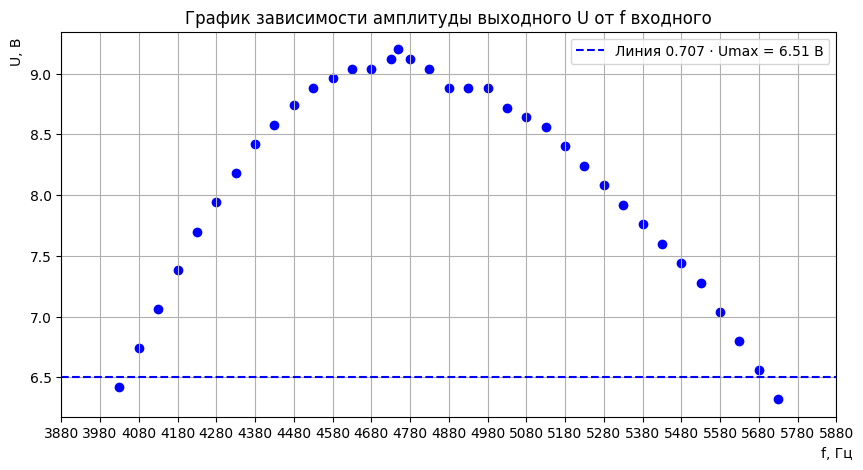

In [128]:
plt.figure(figsize=(10,5))

plt.scatter(direct1['f'], direct1['U'], color='blue', marker='o')
plt.axhline(Uh_p, color='blue', linestyle='--', label=f'Линия 0.707 ⋅ Umax = {Uh_p:.2f} В')

# plt.plot(f, Uc, color='green')
# plt.axhline(Uh_t, color='green', linestyle='--', label=f'Теор. уровень 0.707 Umax = {Uh_t:.2f} В')


plt.title("График зависимости амплитуды выходного U от f входного")
plt.xlabel("f, Гц")
plt.ylabel("U, В")
plt.xticks(np.arange(min(direct1['f'])-150, max(direct1['f']) + 1 + 150, 100))
plt.gca().xaxis.label.set_position((1, 0))
plt.gca().yaxis.label.set_position((0, 0.95))
plt.grid(True)
plt.legend()
plt.show()

##### Обработка 2

$Q = \frac{\omega_0}{\Delta\omega}$

$\Delta Q = Q\sqrt{(\frac{\Delta_\omega}{\omega_0})^2 + (\frac{\Delta_\omega}{\Delta\omega})^2}$

In [149]:
dw = 1650
w0 = 4750
Q = w0 / dw

delta_w = 50
delta_Q = Q * np.sqrt((delta_w/w0)**2 + (delta_w/dw)**2)

print(format_rel(w0, delta_w), dw)
print(f"Q = {format_rel(Q, delta_Q)}")

4750 ± 50, ε=1.1% 1650
Q = 2.88 ± 0.09, ε=3.2%


##### Обработка 3

$Q = \frac{1}{R}\sqrt{\frac{L}{C}}$

$\varepsilon_{Q} = \sqrt{\left(\frac{\Delta_R}{R}\right)^2 + \left(\frac{\Delta_L}{2L}\right)^2 + \left(\frac{\Delta_C}{2C}\right)^2}$

In [130]:
Q_theory = 1 / R * math.sqrt(L / C)
d_Q_theory = math.sqrt((d_R/R)**2 + (d_L/(2*L))**2 + (d_C/(2*C))**2)

print(format_rel(Q_theory, d_Q_theory))

4.65 ± 0.12, ε=2.6%


##### Обработка 4-5

$$\omega^2 = \frac{1}{LC} - \frac{R^2}{4L^2} = k\cdot\frac{1}{C} + b$$

$L = \frac{1}{k}$

$\Delta_L = L\frac{\Delta_k}{k}$

$b = \frac{R^2}{4L^2} ⇒ R^2=b\cdot4L^2 ⇒ R = 2L\sqrt{b}$

$\Delta_R = R\sqrt{\left(\frac{\Delta_L}{L}\right)^2 + \left(\frac{\Delta_b}{2b}\right)^2}$

МНК: Ω² = 101.20550106037129·(1/C) + 633042159.4436951
k = 101.2 ± 3.8, ε=3.8%
b = 633042159 ± 1700000000, ε=260%
Найденная индуктивность L_exp = 0.00988 ± 0.00038, ε=3.8% Гн
Заданная индуктивность L_given = 0.01 Гн
Активное сопротивление R_exp ≈ 503.2065816118446 ± 656.9077270768048 Ом 


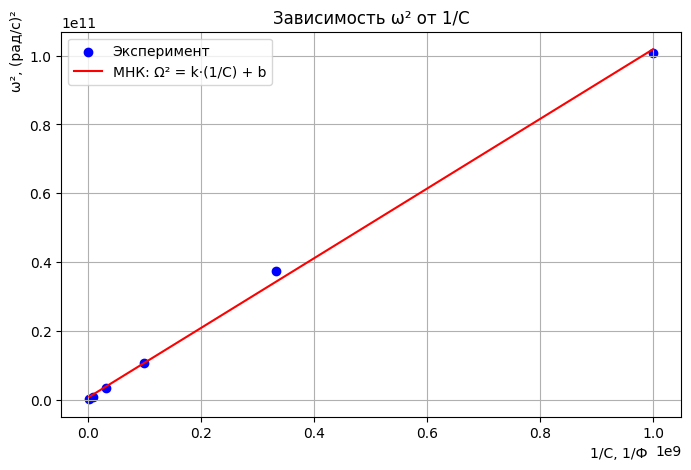

In [143]:
C_ser = direct2["C"]
f_ser = direct2["f"]

x = 1 / C_ser
y = (2 * np.pi * f_ser)**2

# МНК y = kx + b
k, d_k, b, d_b = LMM(list(x), list(y))

L_exp = 1 / k
d_L_exp = d_k * L / k
R_exp = 2 * L * np.sqrt(b)
d_R_exp = R_exp * np.sqrt((d_L_exp/L_exp)**2 + (d_b/(2*b))**2)

print(f'МНК: Ω² = {k}·(1/C) + {b}')
print(f"k = {format_rel(k, d_k)}")
print(f"b = {format_rel(b, d_b)}")
print(f"Найденная индуктивность L_exp = {format_rel(L_exp, d_L_exp)} Гн")
print(f"Заданная индуктивность L_given = {L} Гн")
print(f"Активное сопротивление R_exp ≈ {R_exp} ± {d_R_exp} Ом ")

plt.figure(figsize=(8,5))
plt.scatter(x, y, color='blue', label='Эксперимент')
plt.plot(x, k * x + b, color='red', label=f'МНК: Ω² = k·(1/C) + b')
plt.xlabel('1/C, 1/Ф')
plt.ylabel('ω², (рад/с)²')
plt.title('Зависимость ω² от 1/C')
plt.gca().xaxis.label.set_position((0.9, 0))
plt.gca().yaxis.label.set_position((0, 0.95))
plt.grid(True)
plt.legend()
plt.show()

### Окончательные

In [152]:
print(latex_rel(f_theory, d_f_theory))
print(latex_rel(w0, delta_w))
print(latex_rel(Q_theory, d_Q_theory))
print(latex_rel(Q, delta_Q))
print(latex_rel(L_exp, d_L_exp))

5033 \pm 360, \varepsilon=7%
4750 \pm 50, \varepsilon=1.1%
4.65 \pm 0.12, \varepsilon=2.6%
2.88 \pm 0.09, \varepsilon=3.2%
0.00988 \pm 0.00038, \varepsilon=3.8%
